In [14]:
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.RobotController import RobotController
from optimal.configuration import UR10
import optimal.metrics as metrics
import numpy as np

type = UR10
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

def objective(trial, DT, path):
    # Ask Optuna to guess the weights (we use log scale because weights can vary wildly)
    track_weight          = trial.suggest_float("track_weight",          1e-5, 1e5,  log=True)
    ctrl_weight           = trial.suggest_float("ctrl_weight",           1e-5, 1e5,  log=True)
    terminal_pose_weight  = trial.suggest_float("terminal_pose_weight",  1e-5,  1e7,  log=True)
    v_weight              = trial.suggest_float("v_weight",              1e-5,  1e5,  log=True)
    acc_weight            = trial.suggest_float("acc_weight",            1e-5,  1e7,  log=True)
    
    # Initialize your controller
    controller = RobotController(robot_pin_model)
    xs, us = [], []   
    terminal_error_q = 0.0 
    terminal_error_v = 0.0
    
    try:
        nq = len(robot_pin_model.q_indices)
        nv = len(robot_pin_model.v_indices)
        current_q = path[0]
        current_v = np.zeros(nv)
        
        for i in range(1, len(path)):
            target_q = path[i]
            x_start = np.concatenate([current_q, current_v])
            x_goal  = np.concatenate([target_q, np.zeros(nv)])
            
            t_xs, t_us = controller.compute_control(x_start=x_start, 
                                                    x_goal=x_goal, 
                                                    T=1000, DT=DT, kp=type.kp, kd=type.kd,
                                                    track_weight=track_weight, 
                                                    ctrl_weight=ctrl_weight, 
                                                    terminal_pose_weight=terminal_pose_weight,
                                                    v_weight=v_weight,
                                                    acc_weight=acc_weight,
                                                    option="crocoddyl_advanced")
            
            actual_q = t_xs[-1][:nq]
            actual_v = t_xs[-1][nq:]
            
            # terminal error evaluated at the end of each segment
            terminal_error_q += metrics.terminal_error(actual_q, target_q)
            terminal_error_v += np.linalg.norm(actual_v)
            
            xs.extend(t_xs)
            us.extend(t_us)
            current_q = actual_q
            current_v = actual_v
            
            # If the robot is already failing to reach intermediate targets, we could penalize early (optional)
            
    except Exception as e:
        # If the solver crashes (e.g. weights were numerically unstable), 
        # return a massive penalty so Optuna knows it was a bad guess.
        print(f"Solver failed with error: {e}")
        return float('inf')

    # --- Evaluate the Metric (How good was the result?) ---
    control_effort = metrics.thermal_energy(us, DT)
    torque_jerk = metrics.torque_jerk(us)
    mechanical_work = metrics.mechanical_work(us, xs, DT)
    peak_power = metrics.peak_power(us, xs, DT)
    
    # Notice we weigh terminal error heavily because missing the target is a failure.
    metric_score = (1e5 * terminal_error_q) + (1e5 * terminal_error_v) + (20 * control_effort) + (10 * torque_jerk) + (10 * mechanical_work) + (10 * peak_power)
    
    # If the score is NaN (diverged), penalize it
    if np.isnan(metric_score):
        return float('inf')
        
    return metric_score


In [15]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]

# === Approach 1: Globally tune weights for the entire path ===
study = optuna.create_study(direction="minimize")
# 100 trials is a relatively good start for tuning 5 hyperparameters
study.optimize(lambda trial: objective(trial, DT, path), n_trials=100, show_progress_bar=True)

print("Best global parameters:", study.best_params)
print("Best global score:", study.best_value)

# Duplicate parameters for each segment so later code can just use params[i]
params = [study.best_params for _ in range(len(path) - 1)]

  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 76. Best value: 998638: 100%|██████████| 100/100 [08:03<00:00,  4.83s/it]    

Best global parameters: {'track_weight': 590.5660399753805, 'ctrl_weight': 0.9733400685654615, 'terminal_pose_weight': 787797.1843068051, 'v_weight': 2.4396912637380415, 'acc_weight': 0.301110658868654}
Best global score: 998637.6869399524


In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]

# === Approach 2: Tune weights for each segment individually ===
# (Useful if some movements are short/precise and others are long sweeps)

params_per_segment = []
current_q = path[0]

for i in range(1, len(path)):
    print(f"--- Evaluating Path Segment {i}/{len(path)-1} ---")
    study = optuna.create_study(direction="minimize")
    
    # We create a sub-path of just the start (current_q) and target (path[i]).
    sub_path = [current_q, path[i]]
    func = lambda trial: objective(trial, DT, sub_path)
    
    study.optimize(func, n_trials=50, show_progress_bar=True)
    params_per_segment.append(study.best_params)
    print(f"Best score for segment {i}: {study.best_value}")
    
    # We assume the tuner successfully reaches the target (or very close),
    # so the next segment starts from the target position.
    current_q = path[i]

print("\n=== All Best Coefficients (Per Segment) ===")
for i, param in enumerate(params_per_segment):
    print(f"Segment {i+1}: {param}")

# Uncomment below if you want the subsequent simulation cells to use per-segment params
# params = params_per_segment

--- Evaluating Path 1/5 ---
Starting Optuna search...


Best trial: 0. Best value: inf: 100%|██████████| 100/100 [00:00<00:00, 146.80it/s]


--- Evaluating Path 2/5 ---
Starting Optuna search...


Best trial: 0. Best value: inf: 100%|██████████| 100/100 [00:00<00:00, 169.57it/s]


--- Evaluating Path 3/5 ---
Starting Optuna search...


...

--- Evaluating Path 4/5 ---
Starting Optuna search...


Best trial: 0. Best value: inf: 100%|██████████| 100/100 [00:00<00:00, 151.95it/s]


--- Evaluating Path 5/5 ---
Starting Optuna search...


Best trial: 0. Best value: inf: 100%|██████████| 100/100 [00:00<00:00, 167.85it/s]


=== All Best Coefficients ===
Path 1: {'track_weight': 17136.383019411038, 'ctrl_weight': 41415.4868553629, 'terminal_pose_weight': 919192.1536874652, 'v_weight': 6333761.053728829, 'acc_weight': 4618476.528456467}
Path 2: {'track_weight': 44077.21745217071, 'ctrl_weight': 50631.16326422329, 'terminal_pose_weight': 2914833.503136138, 'v_weight': 8547075.320390835, 'acc_weight': 7900882.500196844}
Path 3: {'track_weight': 63626.13510461461, 'ctrl_weight': 49116.11313576433, 'terminal_pose_weight': 6435423.3171876315, 'v_weight': 9453036.230227398, 'acc_weight': 2578942.0881164744}
Path 4: {'track_weight': 68579.41460578592, 'ctrl_weight': 67410.21113814597, 'terminal_pose_weight': 1620067.2996074033, 'v_weight': 4284882.193126454, 'acc_weight': 5777601.730575915}
Path 5: {'track_weight': 18005.3858448006, 'ctrl_weight': 12377.951329343967, 'terminal_pose_weight': 8217469.008841279, 'v_weight': 5270556.3671350945, 'acc_weight': 6445170.604092841}


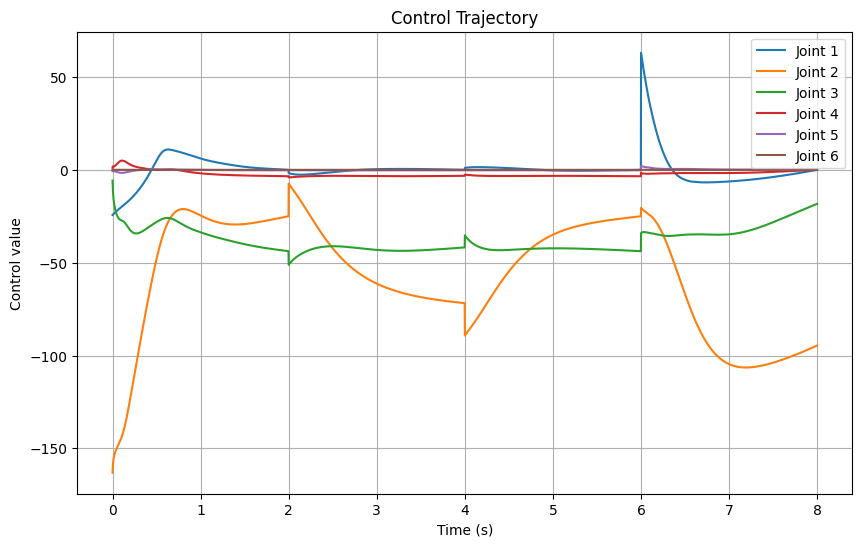

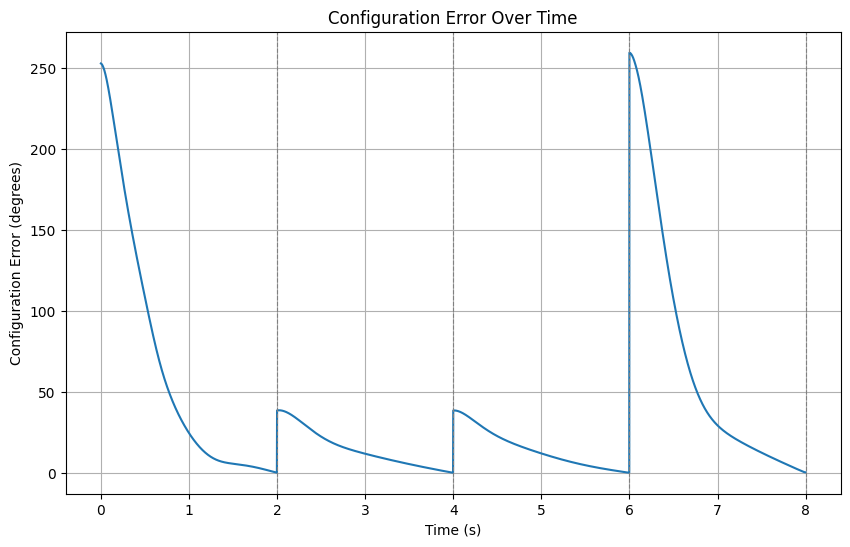

In [16]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox
from optimal.metrics import thermal_energy, mechanical_work, peak_power
import numpy as np

type = UR10_sandbox
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]
controller = RobotController(robot_pin_model)
xs, us = [], []
v_start = np.zeros(len(robot_pin_model.v_indices))
start = np.concatenate([path[0], v_start])
for i in range(len(path) - 1):
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                        x_goal=target, 
                                        T=1000, DT=DT, kp=type.kp, kd=type.kd,
                                        option="crocoddyl_advanced", 
                                        track_weight=params[i]['track_weight'], 
                                        ctrl_weight=params[i]['ctrl_weight'], 
                                        terminal_pose_weight=params[i]['terminal_pose_weight'],
                                        v_weight=params[i]['v_weight'],
                                        acc_weight=params[i]['acc_weight'])
    start = np.concatenate([t_xs[-1][:len(robot_pin_model.q_indices)], t_xs[-1][len(robot_pin_model.q_indices):]])
    xs.extend(t_xs)
    us.extend(t_us)
    v_start = xs[-1][len(robot_pin_model.q_indices):]  # Update v_start for the next segment

# xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
# xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
# xs_real, us_real = robot_mj_model.simulate_control(us=us)
# xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=type.kp, kd=type.kd)
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
# xs_real, us_real = robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
# robot_mj_model.plot_controls(us, dt=DT)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)

In [11]:
robot_mj_model.reset()
# xs_real, us_real = robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
# xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)


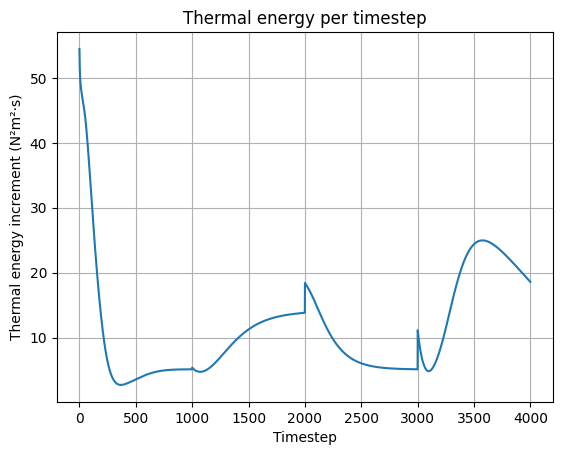

Thermal energy: 46289.54903464777


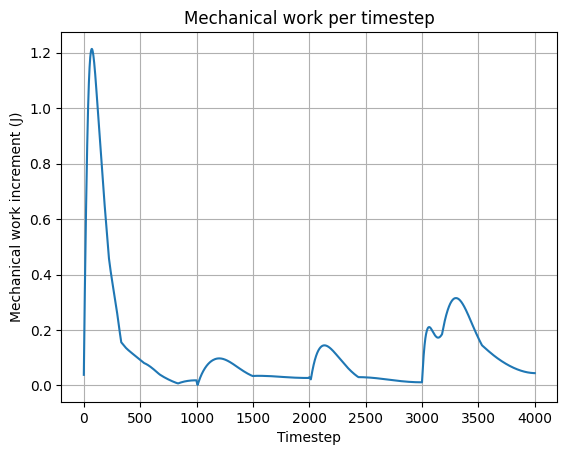

Mechanical work: 521.0802727099341


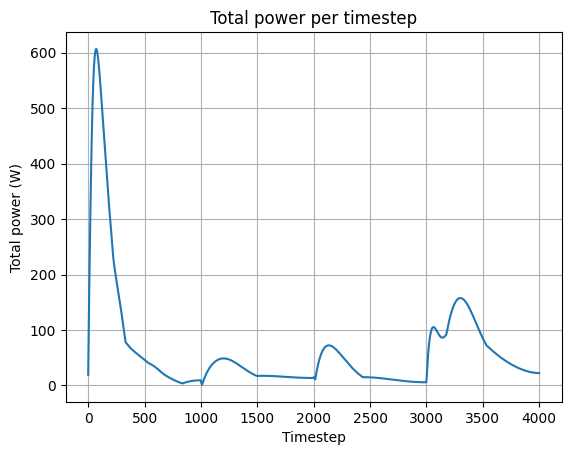

Peak power: 606.7647800002292


In [17]:
E_th  = thermal_energy(us_real, DT, True)
print("Thermal energy:", E_th)
E_mech = mechanical_work(us_real, xs_real, DT, True)
print("Mechanical work:", E_mech)
P_peak = peak_power(us_real, xs_real, True)
print("Peak power:", P_peak)

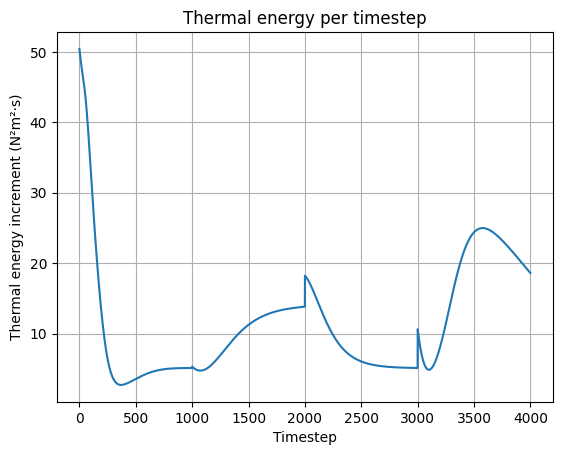

Thermal energy: 46290.9451494658


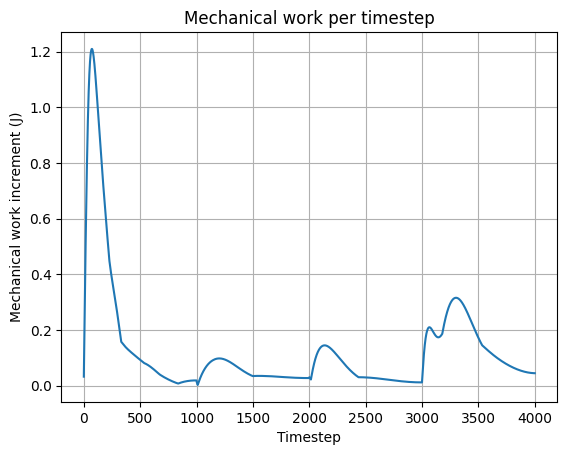

Mechanical work: 520.9473952727097


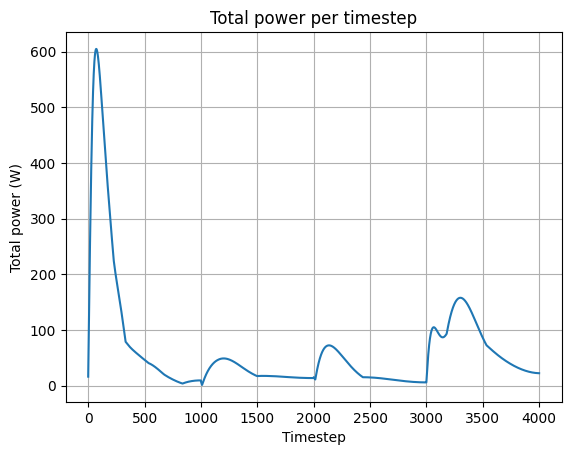

Peak power: 605.0289247236261


In [18]:
E_th  = thermal_energy(us, DT, True)
print("Thermal energy:", E_th)
E_mech = mechanical_work(us, xs, DT, True)
print("Mechanical work:", E_mech)
P_peak = peak_power(us, xs, True)
print("Peak power:", P_peak)